<a href="https://colab.research.google.com/github/ANGB022210151/AquacultureProject/blob/main/step_6_lstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training sequences: 3908
Testing sequences: 977


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 0.0531 - val_loss: 0.0202
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0209 - val_loss: 0.0163
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0185 - val_loss: 0.0135
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0168 - val_loss: 0.0111
Epoch 5/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0155 - val_loss: 0.0090
Epoch 6/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0149 - val_loss: 0.0083
Epoch 7/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0144 - val_loss: 0.0085
Epoch 8/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0140 - val_loss: 0.0085
Epoch 9/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0135 - val_loss: 0.0091
Epoch 10/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0130 - val_loss: 0.0092
Epoch 11/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0126 - val_loss: 0.0101
Epoch 12/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0

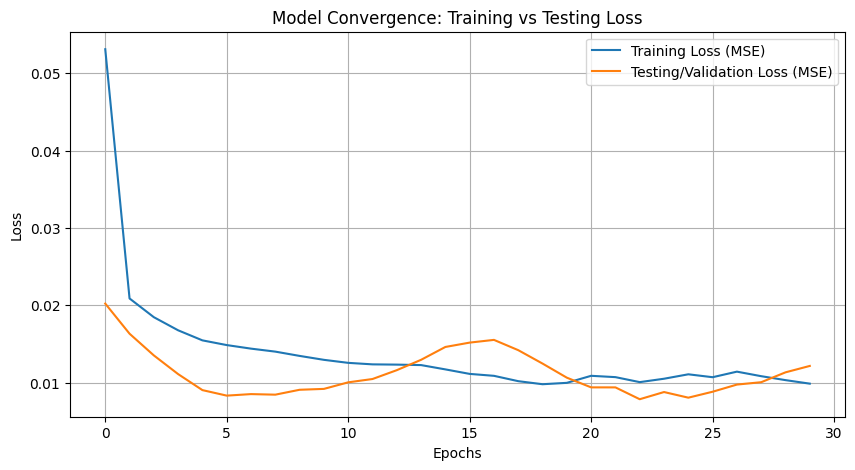

In [3]:
# ==========================================
# Step 1: Imports and Data Loading
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Load the inference dataset
df = pd.read_csv('final_inference_results.csv')

# Ensure chronological order by parsing 'time' and sorting
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)

# ==========================================
# Step 2: Feature Selection & Preprocessing
# ==========================================
# Define input features as specified
input_features = [
    'temperature_cleaned', 'tds_cleaned', 'turbidity_cleaned', 'pH_cleaned',
    'Rate of Change (ΔT/Δt)', 'Moving Average Deviation',
    'Short-Term Gradient (ΔNTU)', 'Rolling Variance (σ²ₚₕ)'
]

# We are forecasting the raw sensors 30 minutes ahead to detect degradation trends
target_features = ['temperature_cleaned', 'tds_cleaned', 'turbidity_cleaned', 'pH_cleaned']

# Drop NaN values that were introduced by rolling windows/engineered features
df_clean = df.dropna(subset=input_features).copy()

# Scale the data (LSTMs are highly sensitive to unscaled data)
# We use two scalers: one for all inputs, and one specifically for targets to easily invert predictions later
X_scaler = MinMaxScaler(feature_range=(0, 1))
y_scaler = MinMaxScaler(feature_range=(0, 1))

scaled_inputs = X_scaler.fit_transform(df_clean[input_features])
scaled_targets = y_scaler.fit_transform(df_clean[target_features])

# ==========================================
# Step 3: Sequence Windowing & Prediction Horizon
# ==========================================
def create_sequences(inputs, targets, seq_length, horizon):
    """
    inputs: Array of scaled input features
    targets: Array of scaled target features
    seq_length: Number of past time steps to look at (e.g., 8 steps = 2 hours)
    horizon: How far into the future to predict (e.g., 2 steps = 30 minutes)
    """
    X, y = [], []
    for i in range(len(inputs) - seq_length - horizon + 1):
        # Sequence of past data
        X.append(inputs[i : i + seq_length])
        # Target data at 'horizon' steps ahead
        y.append(targets[i + seq_length + horizon - 1])

    return np.array(X), np.array(y)

SEQ_LENGTH = 8   # Look back 2 hours (8 * 15 mins)
HORIZON = 2      # Predict 30 mins ahead (2 * 15 mins)

X, y = create_sequences(scaled_inputs, scaled_targets, SEQ_LENGTH, HORIZON)

# ==========================================
# Step 4: Chronological Splitting (80% / 20%)
# ==========================================
split_index = int(len(X) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(f"Training sequences: {X_train.shape[0]}")
print(f"Testing sequences: {X_test.shape[0]}")

# ==========================================
# Step 5: Model Architecture & Training
# ==========================================
model = Sequential()
model.add(LSTM(units=64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(units=32, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=len(target_features)))

model.compile(optimizer='adam', loss='mse')

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, y_test),
    shuffle=False,
    verbose=1
)

# --- NEW: SAVE THE MODEL ---
# You can save it as an .h5 file or the newer .keras format
model.save('predictive_maintenance_lstm.keras')
print("Model saved successfully as 'predictive_maintenance_lstm.keras'")

import joblib
joblib.dump(X_scaler, 'X_scaler.joblib')
joblib.dump(y_scaler, 'y_scaler.joblib')

# ==========================================
# Step 6: Detailed Evaluation (Train vs Test Error)
# ==========================================
# 1. Get predictions for both sets
train_preds_scaled = model.predict(X_train)
test_preds_scaled = model.predict(X_test)

# 2. Invert scaling to get real-world values
train_preds = y_scaler.inverse_transform(train_preds_scaled)
train_actuals = y_scaler.inverse_transform(y_train)

test_preds = y_scaler.inverse_transform(test_preds_scaled)
test_actuals = y_scaler.inverse_transform(y_test)

# 3. Create a comparison table for RMSE
print("\n" + "="*50)
print(f"{'Sensor Name':<25} | {'Train RMSE':<10} | {'Test RMSE':<10}")
print("-" * 50)

for i, feature in enumerate(target_features):
    train_rmse = np.sqrt(mean_squared_error(train_actuals[:, i], train_preds[:, i]))
    test_rmse = np.sqrt(mean_squared_error(test_actuals[:, i], test_preds[:, i]))
    print(f"{feature:<25} | {train_rmse:<10.4f} | {test_rmse:<10.4f}")
print("="*50)

# ==========================================
# Step 7: Visualize Training History (Loss Curve)
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss (MSE)')
plt.plot(history.history['val_loss'], label='Testing/Validation Loss (MSE)')
plt.title('Model Convergence: Training vs Testing Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import joblib
from tensorflow.keras.models import load_model

# 1. Load everything
lstm_model = load_model('predictive_maintenance_lstm.keras')
xgb_model = joblib.load('multi_label_xgboost_model.joblib')
X_scaler = joblib.load('X_scaler.joblib')
y_scaler = joblib.load('y_scaler.joblib')

# 2. Prepare your "Recent Data" (The last 8 rows)
# This should be a dataframe with the same columns used in training
def predict_future_faults(recent_df):
    """
    recent_df: A DataFrame containing the last 8 rows of data
               including the engineered features.
    """
    # Scale the input data
    # (recent_df must have: temp, tds, turb, ph, rate_of_change, dev, gradient, var)
    scaled_input = X_scaler.transform(recent_df)

    # Reshape for LSTM: (1 sample, 8 time steps, 8 features)
    lstm_input = scaled_input.reshape(1, 8, 8)

    # 3. Step A: Predict the raw sensor values 30 minutes in advance
    forecasted_scaled = lstm_model.predict(lstm_input)
    forecasted_values = y_scaler.inverse_transform(forecasted_scaled)

    # Extract the predicted raw values
    f_temp, f_tds, f_turb, f_ph = forecasted_values[0]

    # 4. Step B: Prepare features for XGBoost
    # Since we can't perfectly calculate "Future Variance" without
    # more future data, we use the "Current" engineered values as
    # a proxy, or use the predicted raw values.

    # We take the engineered features from the VERY LAST row of our input
    current_engineered = recent_df.iloc[-1][['Rate of Change (ΔT/Δt)',
                                             'Moving Average Deviation',
                                             'Short-Term Gradient (ΔNTU)',
                                             'Rolling Variance (σ²ₚₕ)']].values

    # Combine [Predicted Raw Sensors] + [Current Trends]
    # This creates the 8-feature row the XGBoost expects
    xgb_input_row = np.array([[f_temp, f_tds, f_turb, f_ph,
                               current_engineered[0], current_engineered[1],
                               current_engineered[2], current_engineered[3]]])

    # 5. Step C: Predict the Fault Label
    predicted_faults = xgb_model.predict(xgb_input_row)

    return forecasted_values[0], predicted_faults[0]

# --- EXAMPLE USAGE ---
latest_8_rows = df_clean.tail(8)[input_features]
future_sensors, future_faults = predict_future_faults(latest_8_rows)

print(f"30-Min Forecasted pH: {future_sensors[3]}")
print(f"Predicted Faults at that time: {future_faults}")